# Dashboard #4 — Model Training

Trains the final `LogisticRegression` recession-probability model on the feature set from
`03_feature_engineering.ipynb`: `BAA10Y`, `CFNAI`, `ICSA`, `is_inverted`, `INDPRO` — target
`SAHMREALTIME` window at h=6 months.

Note: an earlier version of this feature set also included `PAYEMS`, dropped after the VIF
check below revealed severe multicollinearity with `INDPRO` (VIF > 245). That step is not
reproduced here, but is documented for context.

In [12]:
import pandas as pd

combined = pd.read_csv('../data/processed/model_input_h6.csv', index_col=0, parse_dates=True)

feature_cols = ['BAA10Y', 'CFNAI', 'ICSA', 'is_inverted', 'INDPRO']
X = combined[feature_cols]
y = combined['SAHMREALTIME']



## Multicollinearity check (VIF)

Variance Inflation Factor per feature — checks whether any feature is (near-)fully explained
by a linear combination of the others, which would make individual coefficients unreliable
even if the model's overall predictive performance looks fine.

`add_constant()` is required before calling `variance_inflation_factor` — statsmodels doesn't
add an intercept automatically, and omitting it produces inflated, non-comparable VIF values
(a first pass without it briefly suggested a false multicollinearity problem in `BAA10Y` and
`INDPRO`, before the fix). The `const` row itself typically shows a high VIF when features
aren't centered near zero — that's expected and not meaningful; only the feature rows matter.

Result: all features comfortably below the VIF≈5 concern threshold — this feature set is
clean.

In [13]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
vif_data

,feature,VIF
0,const,56.561683
1,BAA10Y,1.264532
2,CFNAI,1.280033
3,ICSA,1.286041
4,is_inverted,1.126345
5,INDPRO,1.155078


## Train/test split

A single chronological hold-out for final reporting metrics, distinct from the 5-fold CV
used during screening. Uses the *last* `TimeSeriesSplit` fold as the test set — i.e. the most
recent ~20% of the series — so the reported metrics reflect performance on genuinely unseen,
most-recent data rather than a cross-validated average.

In [14]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

## Fit model, inspect coefficients

`class_weight='balanced'` compensates for the ~25% positive class rate without resorting to
synthetic resampling (SMOTE), which doesn't respect temporal ordering. `StandardScaler` is
fit only on the train fold, inside the `Pipeline`, avoiding leakage through global
normalization statistics.

Coefficient signs are a sanity check on their own: `CFNAI`/`INDPRO` negative (stronger
economy → lower risk) and `BAA10Y`/`ICSA` positive (credit stress / rising jobless claims →
higher risk) all match economic intuition. `is_inverted`, however, comes back negative —
counter to the textbook expectation that a yield-curve inversion should raise recession risk.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced'))
])

pipe.fit(X_train, y_train)

pd.Series(pipe.named_steps['clf'].coef_[0], index=feature_cols).sort_values()

CFNAI         -1.376137
is_inverted   -0.786551
INDPRO        -0.502627
BAA10Y         0.234855
ICSA           1.322653
dtype: float64

## Investigating the is_inverted sign

Checking the raw relationship in the data, independent of the model, to see whether the
negative coefficient is a modeling artifact or a genuine pattern in the data.

Result: mean target value is *lower* when `is_inverted=1` (0.146) than when `is_inverted=0`
(0.263) — so the model isn't misbehaving, it's accurately reflecting what's in the data.

Most likely explanation: the yield curve's historical lead time before a recession is long
and inconsistent (anywhere from ~6 to ~24 months), so at a fixed 6-month forecast horizon,
inversions often don't coincide with a Sahm trigger simply because the horizon closes before
the recession materializes — not because the inversion carries no information at longer
horizons. This is consistent with `T10Y2Y`'s weak raw-level performance in the earlier
screening step.

**Decision:** drop `is_inverted` from the final model rather than keep a feature with a
sign that can't be honestly explained to a business audience at this horizon. Documented as
a deliberate, evidence-based exclusion — not an oversight.

In [16]:
combined.groupby('is_inverted')['SAHMREALTIME'].mean()

is_inverted
0    0.262338
1    0.145833
Name: SAHMREALTIME, dtype: float64

## Final feature set (4 indicators)

`BAA10Y`, `CFNAI`, `ICSA`, `INDPRO` — refit on the same train/test split. All four
coefficients now have signs consistent with economic intuition, with no unexplained anomalies.

In [17]:
feature_cols = ['BAA10Y', 'CFNAI', 'ICSA', 'INDPRO']
X = combined[feature_cols]
y = combined['SAHMREALTIME']

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced'))
])

pipe.fit(X_train, y_train)

pd.Series(pipe.named_steps['clf'].coef_[0], index=feature_cols).sort_values()

CFNAI    -1.328148
INDPRO   -0.567362
BAA10Y    0.334481
ICSA      1.336861
dtype: float64

## Evaluation metrics

Accuracy is not used given the class imbalance (~25% positive). PR-AUC is the primary metric
(more informative than ROC-AUC under imbalance); Brier score checks probability calibration,
since the dashboard output is a probability, not just a class label; recall/precision give an
interpretable operating-point view.

ROC/PR curves are visibly "stepped" rather than smooth — expected given the small test fold
(~87 months, ~20 positive), not a modeling issue. Final result on this feature set: PR-AUC
0.76 (up from 0.73 with the flawed 5-feature version), ROC-AUC 0.78.

PR-AUC: 0.7611228147394332
Brier score: 0.12803443790008284
Recall: 0.5714285714285714
Precision: 0.9230769230769231


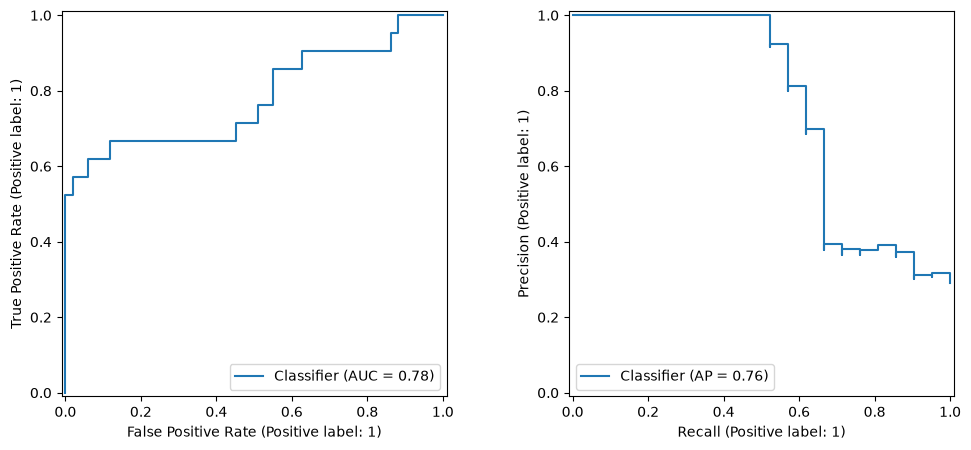

In [18]:
from sklearn.metrics import average_precision_score, brier_score_loss, recall_score, precision_score, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)

print('PR-AUC:', average_precision_score(y_test, y_proba))
print('Brier score:', brier_score_loss(y_test, y_proba))
print('Recall:', recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
plt.show()

## Save the trained model

Persisted for reuse when generating predicted probabilities across the full historical range
in the next step (export to PostgreSQL for Power BI).

In [19]:
import joblib
joblib.dump(pipe, '../data/processed/recession_model_h6.pkl')

['../data/processed/recession_model_h6.pkl']